In [1]:
# =========================
# Cell 1 — Imports
# =========================
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    matthews_corrcoef
)

In [2]:
# =========================
# Cell 2 — File paths (Colab /content)
# Upload your files to Colab: Runtime > Files > Upload
# =========================
TFIDF_CSV = "/content/HDFS_tfidf_full.csv"
LABEL_CSV = "/content/anomaly_label.csv"   # optional

assert os.path.exists(TFIDF_CSV), f"Missing: {TFIDF_CSV}"
print("TFIDF file found.")

HAS_LABELS = os.path.exists(LABEL_CSV)
print("Label file found?" , HAS_LABELS)

TFIDF file found.
Label file found? True


In [3]:
# =========================
# Cell 3 — Load CSVs
# =========================
tfidf_df = pd.read_csv(TFIDF_CSV)
tfidf_df.columns = [c.strip() for c in tfidf_df.columns]

if HAS_LABELS:
    lab_df = pd.read_csv(LABEL_CSV)
    lab_df.columns = [c.strip() for c in lab_df.columns]
    print("TFIDF:", tfidf_df.shape, "| LABEL:", lab_df.shape)
    print("LABEL columns:", lab_df.columns.tolist())
else:
    print("TFIDF:", tfidf_df.shape)

TFIDF: (575061, 49) | LABEL: (575061, 2)
LABEL columns: ['BlockId', 'Label']


In [4]:
# =========================
# Cell 4 — Auto-detect join key + label column, merge labels (if provided)
# Same style as your Isolation Forest notebook
# =========================
ID_CANDIDATES    = ["blockid","block_id","block","blk_id","BlockId","BlockID","id","Id"]
LABEL_CANDIDATES = ["label","labels","anomaly","is_anomaly","y","target","class"]

def detect_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

if HAS_LABELS:
    JOIN_COL  = detect_col(lab_df, ID_CANDIDATES)
    LABEL_COL = detect_col(lab_df, LABEL_CANDIDATES)

    if JOIN_COL is None:
        raise ValueError("Could not auto-detect JOIN_COL in label file.")
    if LABEL_COL is None:
        raise ValueError("Could not auto-detect LABEL_COL in label file.")

    tfidf_join = detect_col(tfidf_df, ID_CANDIDATES)
    if tfidf_join is None:
        raise ValueError("Could not auto-detect join column in TFIDF file.")

    # rename feature join column to match label join column
    tfidf_m = tfidf_df.rename(columns={tfidf_join: JOIN_COL}).merge(
        lab_df[[JOIN_COL, LABEL_COL]], on=JOIN_COL, how="inner"
    )

    print("Merged TFIDF:", tfidf_m.shape)
    print("Detected JOIN_COL:", JOIN_COL, "| LABEL_COL:", LABEL_COL)
else:
    tfidf_m = tfidf_df.copy()
    JOIN_COL = detect_col(tfidf_m, ID_CANDIDATES)  # may exist, maybe not
    LABEL_COL = None

Merged TFIDF: (575061, 50)
Detected JOIN_COL: BlockId | LABEL_COL: Label


In [5]:
# =========================
# Cell 5 — Build X (and y if labels exist)
# =========================
def make_X_y(df, join_col=None, label_col=None):
    y = None
    if label_col is not None:
        y_raw = df[label_col]
        if pd.api.types.is_numeric_dtype(y_raw):
            y = (y_raw.astype(float) > 0).astype(int).values
        else:
            y_str = y_raw.astype(str).str.lower()
            y = y_str.isin(["1","true","anomaly","yes","y","abnormal"]).astype(int).values

    drop_cols = []
    if join_col is not None and join_col in df.columns:
        drop_cols.append(join_col)
    if label_col is not None and label_col in df.columns:
        drop_cols.append(label_col)

    X = df.drop(columns=drop_cols, errors="ignore")

    # numeric conversion
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.fillna(0.0)

    return X.values, y

X, y = make_X_y(tfidf_m, JOIN_COL, LABEL_COL)
print("X shape:", X.shape)
if y is not None:
    print("y shape:", y.shape, "| anomaly rate:", y.mean())
else:
    print("No labels → unsupervised scoring only (no F1/AUC).")

X shape: (575061, 48)
y shape: (575061,) | anomaly rate: 0.029280371995318757


In [6]:
# =========================
# Cell 6 — Scale features (IMPORTANT for PCA/IPCA)
# PCA is variance-based → scaling is required
# =========================
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

print("Scaled X:", X_scaled.shape, "| mean:", X_scaled.mean().round(4), "| std:", X_scaled.std().round(4))

Scaled X: (575061, 48) | mean: -0.0 | std: 1.0


In [7]:
# =========================
# Cell 7 — Choose number of components (PCA)
# Option A: fixed k
# =========================
k = 40   # try 20, 50, 100
pca = PCA(n_components=k, random_state=42)
Z = pca.fit_transform(X_scaled)

print("Z shape:", Z.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

Z shape: (575061, 40)
Explained variance ratio sum: 0.9999815345207151


In [8]:
# =========================
# Cell 8 — PCA Reconstruction Error (anomaly score)
# =========================
X_hat = pca.inverse_transform(Z)
recon_error_pca = np.mean((X_scaled - X_hat) ** 2, axis=1)  # MSE per sample

print("PCA recon_error: min/mean/max =",
      np.min(recon_error_pca), np.mean(recon_error_pca), np.max(recon_error_pca))

PCA recon_error: min/mean/max = 2.5825014220548618e-12 1.8465479285640876e-05 0.3965414495377952


In [9]:
# =========================
# Cell 9 — Thresholding (default rule)
# If labels exist: pick threshold by contamination = anomaly rate
# If no labels: pick top 1% as anomalies
# =========================
if y is not None:
    contamination = float(np.mean(y))
else:
    contamination = 0.01  # 1%

thr_pca = np.quantile(recon_error_pca, 1 - contamination)
yhat_pca = (recon_error_pca >= thr_pca).astype(int)

print("Contamination:", contamination)
print("Threshold (PCA):", thr_pca)
print("Predicted anomaly rate:", yhat_pca.mean())

Contamination: 0.029280371995318757
Threshold (PCA): 4.541530620232151e-07
Predicted anomaly rate: 0.030010729296544192


In [10]:
def eval_predictions(y_true, y_pred, anomaly_scores=None, title=""):
    cm = confusion_matrix(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred)  # ✅ ADDED

    print("\n" + "="*80)
    print(title)
    print("Confusion matrix [ [TN FP], [FN TP] ]:\n", cm)
    print(f"Precision: {pr:.4f} | Recall: {rc:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")  # ✅ UPDATED

    if anomaly_scores is not None:
        try:
            auc = roc_auc_score(y_true, anomaly_scores)
            print(f"ROC-AUC (score-based): {auc:.4f}")
        except Exception as e:
            print("ROC-AUC not computed:", e)

    print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))

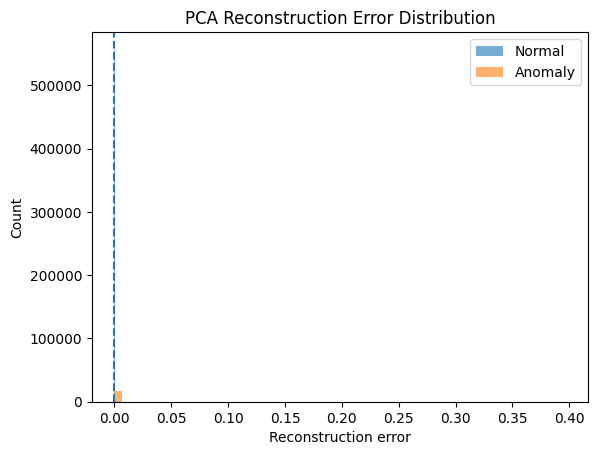

In [11]:
# =========================
# Cell 11 — Visualization: score distribution
# =========================
plt.figure()
if y is not None:
    plt.hist(recon_error_pca[y==0], bins=60, alpha=0.6, label="Normal")
    plt.hist(recon_error_pca[y==1], bins=60, alpha=0.6, label="Anomaly")
    plt.legend()
else:
    plt.hist(recon_error_pca, bins=80, alpha=0.8)
plt.axvline(thr_pca, linestyle="--")
plt.title("PCA Reconstruction Error Distribution")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.show()

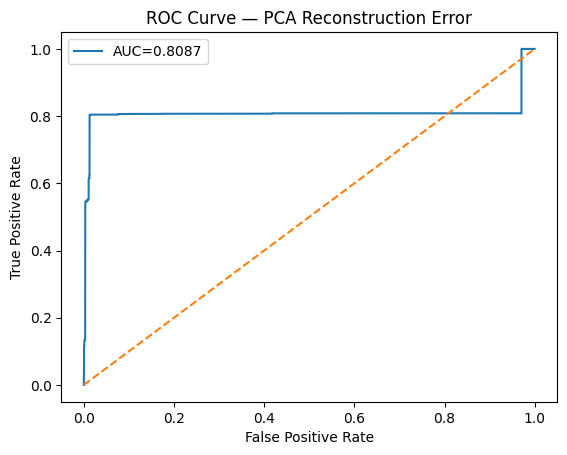

In [12]:
# =========================
# Cell 12 — ROC curve (if labels exist)
# =========================
if y is not None:
    fpr, tpr, _ = roc_curve(y, recon_error_pca)
    auc = roc_auc_score(y, recon_error_pca)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title("ROC Curve — PCA Reconstruction Error")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [13]:
# =========================
# Cell 13 — IPCA fit (mini-batch)
# =========================
k_ipca = 40  # or pick by explained variance target
batch_size = 2000  # tune based on Colab RAM
ipca = IncrementalPCA(n_components=k_ipca, batch_size=batch_size)

# partial_fit in batches
for start in range(0, X_scaled.shape[0], batch_size):
    end = min(start + batch_size, X_scaled.shape[0])
    ipca.partial_fit(X_scaled[start:end])

Z_ipca = ipca.transform(X_scaled)

print("Z_ipca shape:", Z_ipca.shape)

Z_ipca shape: (575061, 40)


In [14]:
# =========================
# Cell 14 — IPCA Reconstruction Error (anomaly score)
# =========================
X_hat_ipca = ipca.inverse_transform(Z_ipca)
recon_error_ipca = np.mean((X_scaled - X_hat_ipca) ** 2, axis=1)

print("IPCA recon_error: min/mean/max =",
      np.min(recon_error_ipca), np.mean(recon_error_ipca), np.max(recon_error_ipca))

IPCA recon_error: min/mean/max = 2.959226554396343e-12 1.8465782585301365e-05 0.3963865582603554


In [15]:
print('--- IPCA Reconstruction Error Statistics ---')
print(pd.Series(recon_error_ipca).describe())

--- IPCA Reconstruction Error Statistics ---
count    5.750610e+05
mean     1.846578e-05
std      5.877686e-04
min      2.959227e-12
25%      1.346650e-09
50%      1.346650e-09
75%      3.308722e-08
max      3.963866e-01
dtype: float64


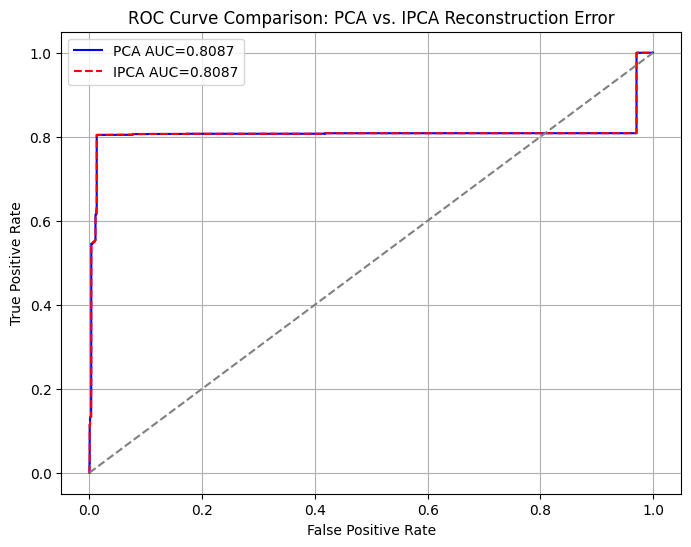

In [16]:
# Recompute ROC curve components for PCA
fpr_pca, tpr_pca, _ = roc_curve(y, recon_error_pca)
auc_pca = roc_auc_score(y, recon_error_pca)

# Recompute ROC curve components for IPCA
fpr_ipca, tpr_ipca, _ = roc_curve(y, recon_error_ipca)
auc_ipca = roc_auc_score(y, recon_error_ipca)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pca, tpr_pca, label=f"PCA AUC={auc_pca:.4f}", color='blue')
plt.plot(fpr_ipca, tpr_ipca, label=f"IPCA AUC={auc_ipca:.4f}", color='red', linestyle='--')
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.title("ROC Curve Comparison: PCA vs. IPCA Reconstruction Error")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

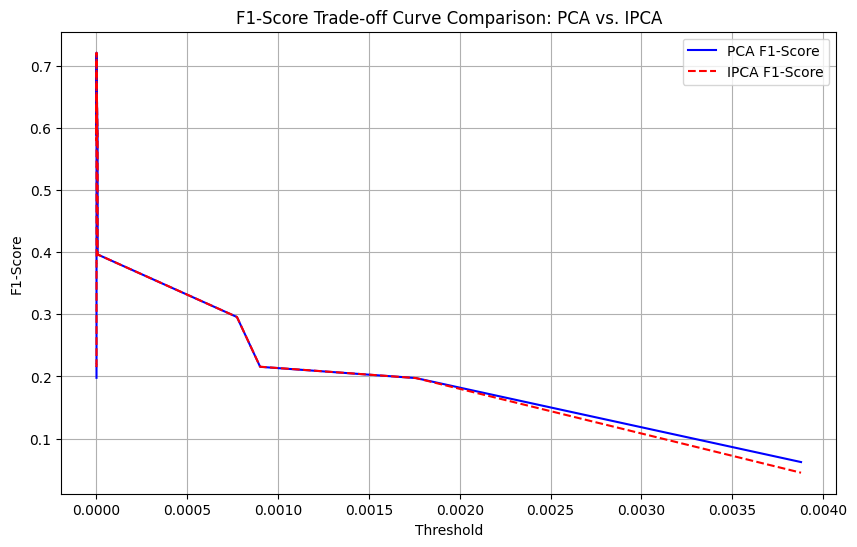

In [17]:
if y is not None:
    # Define common thresholds for comparison
    thresholds_common = np.quantile(np.concatenate((recon_error_pca, recon_error_ipca)), np.linspace(0.80, 0.999, 80))

    # Calculate F1s for PCA
    F1s_pca = []
    for thr in thresholds_common:
        pred_pca = (recon_error_pca >= thr).astype(int)
        _, _, f1_pca, _ = precision_recall_fscore_support(y, pred_pca, average="binary", zero_division=0)
        F1s_pca.append(f1_pca)

    # Calculate F1s for IPCA
    F1s_ipca = []
    for thr in thresholds_common:
        pred_ipca = (recon_error_ipca >= thr).astype(int)
        _, _, f1_ipca, _ = precision_recall_fscore_support(y, pred_ipca, average="binary", zero_division=0)
        F1s_ipca.append(f1_ipca)

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds_common, F1s_pca, label="PCA F1-Score", color='blue')
    plt.plot(thresholds_common, F1s_ipca, label="IPCA F1-Score", color='red', linestyle='--')
    plt.title("F1-Score Trade-off Curve Comparison: PCA vs. IPCA")
    plt.xlabel("Threshold")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
# =========================
# Cell 15 — Thresholding (same rule)
# =========================
thr_ipca = np.quantile(recon_error_ipca, 1 - contamination)
yhat_ipca = (recon_error_ipca >= thr_ipca).astype(int)

print("Threshold (IPCA):", thr_ipca)
print("Predicted anomaly rate:", yhat_ipca.mean())

Threshold (IPCA): 4.5443521876517177e-07
Predicted anomaly rate: 0.03001246824249949


In [19]:
# =========================
# Cell 16 — Evaluation (if labels exist)
# =========================
if y is not None:
    eval_predictions(y, yhat_ipca, anomaly_scores=recon_error_ipca, title="IPCA (Reconstruction Error)")


IPCA (Reconstruction Error)
Confusion matrix [ [TN FP], [FN TP] ]:
 [[551323   6900]
 [  6479  10359]]
Precision: 0.6002 | Recall: 0.6152 | F1: 0.6076 | MCC: 0.5957
ROC-AUC (score-based): 0.8087

Classification report:
               precision    recall  f1-score   support

           0     0.9884    0.9876    0.9880    558223
           1     0.6002    0.6152    0.6076     16838

    accuracy                         0.9767    575061
   macro avg     0.7943    0.8014    0.7978    575061
weighted avg     0.9770    0.9767    0.9769    575061



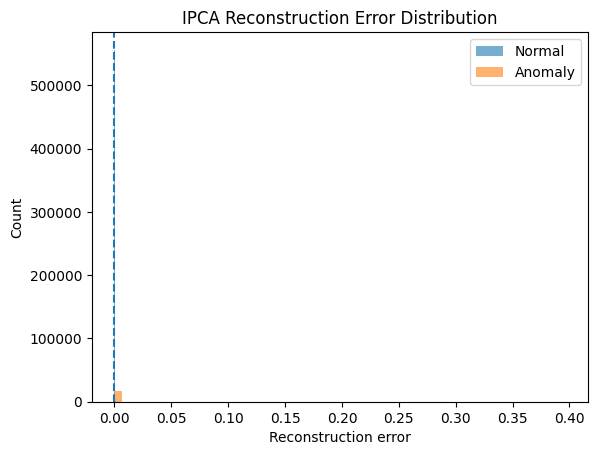

In [20]:
# =========================
# Cell 17 — Visualization: IPCA score distribution
# =========================
plt.figure()
if y is not None:
    plt.hist(recon_error_ipca[y==0], bins=60, alpha=0.6, label="Normal")
    plt.hist(recon_error_ipca[y==1], bins=60, alpha=0.6, label="Anomaly")
    plt.legend()
else:
    plt.hist(recon_error_ipca, bins=80, alpha=0.8)
plt.axvline(thr_ipca, linestyle="--")
plt.title("IPCA Reconstruction Error Distribution")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.show()

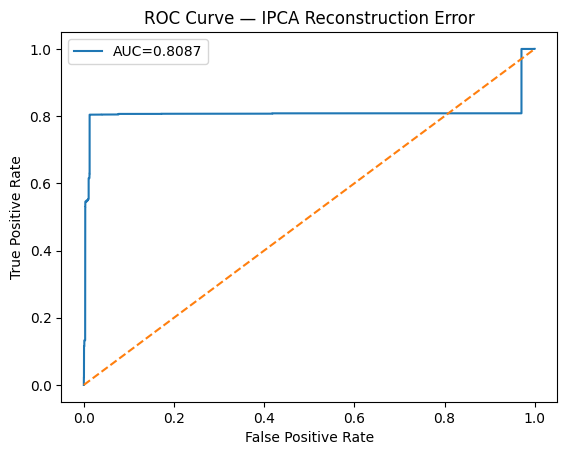

In [21]:
# =========================
# Cell 18 — ROC curve (IPCA) if labels exist
# =========================
if y is not None:
    fpr, tpr, _ = roc_curve(y, recon_error_ipca)
    auc = roc_auc_score(y, recon_error_ipca)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title("ROC Curve — IPCA Reconstruction Error")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [22]:
out = pd.DataFrame({
    "BlockId": tfidf_m[JOIN_COL].astype(str),
    "y_true": y.astype(int),
    "score_pca": recon_error_pca.astype(float),
    "pred_pca": yhat_pca.astype(int)
})
out.to_csv("/content/pca_results.csv", index=False)

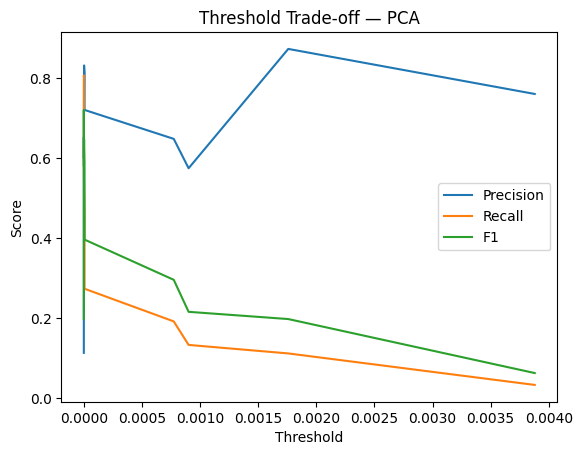

In [23]:
# =========================
# Cell 19 — Threshold trade-off curve (PCA or IPCA)
# Choose which scores you want to tune
# =========================
if y is not None:
    scores = recon_error_pca  # change to recon_error_ipca if you want IPCA
    name   = "PCA"

    thresholds = np.quantile(scores, np.linspace(0.80, 0.999, 80))
    Ps, Rs, F1s = [], [], []

    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
        Ps.append(p); Rs.append(r); F1s.append(f1)

    plt.figure()
    plt.plot(thresholds, Ps, label="Precision")
    plt.plot(thresholds, Rs, label="Recall")
    plt.plot(thresholds, F1s, label="F1")
    plt.title(f"Threshold Trade-off — {name}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

In [24]:
# =========================
# NEW Cell — Fit PCA to 2D for visualization (separate from your k=50 model)
# This is ONLY for plotting, not for detection.
# =========================
pca2 = PCA(n_components=2, random_state=42)
Z2 = pca2.fit_transform(X_scaled)

print("2D PCA explained variance sum:", pca2.explained_variance_ratio_.sum())

2D PCA explained variance sum: 0.2421001661258106


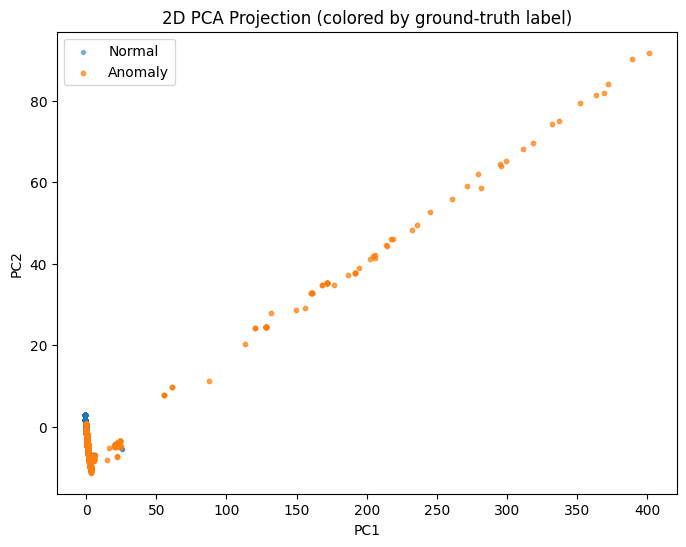

In [25]:
# =========================
# NEW Cell — 2D PCA scatter plot
# - If y exists: color by label
# - If no y: highlight top anomalies by reconstruction error
# =========================
plt.figure(figsize=(8, 6))

if y is not None:
    plt.scatter(Z2[y==0, 0], Z2[y==0, 1], s=8, alpha=0.5, label="Normal")
    plt.scatter(Z2[y==1, 0], Z2[y==1, 1], s=10, alpha=0.7, label="Anomaly")
    plt.legend()
    plt.title("2D PCA Projection (colored by ground-truth label)")
else:
    # Highlight top anomalies by score (use PCA score you already computed)
    top_k = max(50, int(0.01 * len(recon_error_pca)))  # top 1% or at least 50
    idx_sorted = np.argsort(recon_error_pca)[::-1]
    idx_top = idx_sorted[:top_k]

    plt.scatter(Z2[:, 0], Z2[:, 1], s=7, alpha=0.35, label="All points")
    plt.scatter(Z2[idx_top, 0], Z2[idx_top, 1], s=14, alpha=0.9, label=f"Top {top_k} anomalies (by PCA score)")
    plt.legend()
    plt.title("2D PCA Projection (top anomalies highlighted)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()